# AI-Clinical-Rehab-Platform

## 基本設定

In [1]:
import schema
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

# 1. 載入 2026/02/28 診斷完成的乾淨數據
# 此時 load_and_preprocess_subject 已經包含物理濾鏡
data_dict = schema.get_all_subjects_for_analysis()

# 2. 實作受試者級別標準化 (Per-Subject Normalization)
# 這是為了解決 S3 的 Sensor Bias 與 S1/S10 的分佈不一致

print("🧬 執行選擇性標準化 (僅針對 Acc/Mag)...")
print("🧬 正在執行受試者級別標準化 (Per-Subject Normalization)...")

standardized_data = {}
for sid, (X, y) in data_dict.items():
    n_windows, n_steps, n_features = X.shape
    
    # 1. 前 4 欄保持 Z-score 標準化 (處理 S1/S10 個體差異)
    acc_mag_part = X[:, :, :4].reshape(-1, 4)
    scaler = StandardScaler()
    scaled_acc = scaler.fit_transform(acc_mag_part).reshape(n_windows, n_steps, 4)

    # 2. 僅標準化 Acc/Mag 部分
    reshaped_acc = acc_mag_part.reshape(-1, 4)
    scaler = StandardScaler()
    scaled_acc = scaler.fit_transform(reshaped_acc).reshape(n_windows, n_steps, 4)

    # 2. 後 3 欄重力特徵：直接除以 10.0 (Global Scaling)
    # 這樣數值會從 [-10, 10] 變成 [-1, 1]
    # 保留了絕對物理方向，但量級與 Acc 對齊
    gravity_scaled = X[:, :, 4:] / 10.0


    # 3. 合併：重力部分不進行標準化，保留物理絕對值
    X_final = np.concatenate([scaled_acc, gravity_scaled], axis=2)
    standardized_data[sid] = (X_final, y)



    # # 將 3D 數據拉平以便進行 StandardScaler
    # X_reshaped = X.reshape(-1, n_features)
    
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X_reshaped)
    
    # # 還原回 3D 結構
    # X_final = X_scaled.reshape(n_windows, n_steps, n_features)
    # standardized_data[sid] = (X_final, y)

print(f"✅ 完成 {len(standardized_data)} 位受試者的數據校準。")

🧬 執行選擇性標準化 (僅針對 Acc/Mag)...
🧬 正在執行受試者級別標準化 (Per-Subject Normalization)...
✅ 完成 10 位受試者的數據校準。


In [2]:
import importlib
importlib.reload(schema) # 強制重新載入剛存檔的 schema.py

data_dict = schema.get_all_subjects_for_analysis()
test_subject_id = 1
X_sample, _ = data_dict[test_subject_id]

print(f"🕵️ 數據特徵診斷：")
print(f"每個視窗的形狀: {X_sample.shape}") 
# 這裡必須顯示 (視窗數, 128, 7)
if X_sample.shape[2] == 7:
    print("✅ 數據已就緒，可以開始訓練！")
else:
    print(f"❌ 錯誤！數據仍只有 {X_sample.shape[2]} 個特徵，請檢查 schema.py 是否有存檔成功。")

🕵️ 數據特徵診斷：
每個視窗的形狀: (548, 128, 7)
✅ 數據已就緒，可以開始訓練！


## CNN-LSTM 混合模型定義

### 模型介紹
1. CNN (卷積神經網路)
    - 常用類別：Conv1D（用於 1 維序列如感測器）、Conv2D（用於 2 維圖像）。
    - 用途：提取「局部特徵」。在你的復健專案中，它負責偵測加速度計在極短時間內的震動或衝擊。

2. LSTM (長短期記憶網路)
    - 常用類別：LSTM。
    - 用途：處理「時間序列」的長程依賴關係。它能記住 128 個時間點前的狀態，進而分辨「這是在走一步路」還是「這是在坐著晃動」。

### 模型用途
- CNN 負責提取感測器信號中的局部空間特徵（例如 S2/S8 身上看到的瞬時加速度變化）
- LSTM 則負責捕捉時間維度上的規律（例如區分 Sitting 與 Standing 在微小重力偏移上的差異）

### 使用原因
1. BatchNormalization (對應 S1/S10)：
    我們在 KS Test 發現 S1 與 S10 有顯著的分佈偏移。加入 BatchNormalization 層能將每一批次數據的特徵強制重新對齊，降低個體差異對模型權重的衝擊。

2. LSTM 時序特徵 (對應 Sitting vs Standing)：
    單純的 CNN 只能看見「當下」的數值。由於 Sitting 與 Standing 的 Magnitude 都很接近 9.8，LSTM 能夠透過分析整整 128 個點的「細微晃動規律」來區分兩者。

3. Dropout (應對雜訊)：
    雖然 S2/S8 的雜訊比例極低，但 Dropout 能提高模型的魯棒性（Robustness），防止模型過度擬合受試者的特定小動作。




In [3]:
def build_hybrid_model(input_shape, num_classes):
    """
    CNN-LSTM 混合模型架構：
    1. CNN 層：提取空間/局部加速度特徵
    2. LSTM 層：解決 Sitting/Standing 的長時序識別問題
    """
    model = Sequential([
        # --- CNN 特徵提取層 ---
        # 設置 64 個濾波器，卷積核大小為 3，捕捉感測器微小變化
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(), # 加速收斂並應對 S1/S10 的分佈偏移
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # --- LSTM 時序記憶層 ---
        # 使用 64 個單元，捕捉 128 個時間點間的依賴關係
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # --- 全連接輸出層 ---
        Dense(64, activation='relu'),
        # 輸出層：標籤範圍 1-12，因此神經元設為 13 (含索引 0)
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 預定義輸入形狀 (128個時間點, 4個特徵)
# 標籤總數為 13 (對應 mHealth 標籤 1-12)
INPUT_SHAPE = (128, 7)
NUM_CLASSES = 13 

# 初始化模型以確認結構
temp_model = build_hybrid_model(INPUT_SHAPE, NUM_CLASSES)
temp_model.summary()

c:\Users\freea\Desktop\side_project\AI-Clinical-Rehab-Platform\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,693 (155.05 KB)

 Trainable params: 39,565 (154.55 KB)

 Non-trainable params: 128 (512.00 B)

- 卷積層 (Conv1D)：輸出形狀為 (None, 126, 64)。
    * 原本輸入長度為 128，經過大小為 3 的卷積核（$128 - 3 + 1 = 126$），成功提取了加速度計的局部特徵。
- 批次正規化 (BatchNormalization)：解決 S1/S10 分佈偏移的核心。
    * 將 64 個特徵圖進行動態對齊，確保模型不會因為個體動作強度差異而翻車。
- 池化層 (MaxPooling1D)：輸出形狀減半至 (None, 63, 64)。有助於降低運算量，並提取最顯著的運動特徵。
- LSTM 層：輸出形狀為 (None, 64)。
    * 因設置了 return_sequences=False，將 63 個時間片段濃縮成一個具有「時序記憶」的 64 維向量。成功區分     * Sitting 與 Standing 微小差異的關鍵。
- 最後輸出層 (Dense_1)：輸出形狀為 (None, 13)。
    * 對應了 mHealth 的標籤 1-12 加上預留的 0 索引。

In [4]:
results = []

# 遍歷 1 到 10 號受試者，進行 Leave-One-Subject-Out 訓練
for test_sid in range(1, 11):
    print(f"\n🚀 正在啟動 LOSO 實驗：排除 S{test_sid} 作為測試集...")
    
    # 1. 準備數據切分 (使用 2026/03/07 標準化後的數據)
    train_sids = [sid for sid in range(1, 11) if sid != test_sid]
    
    X_train = np.concatenate([standardized_data[sid][0] for sid in train_sids], axis=0)
    y_train = np.concatenate([standardized_data[sid][1] for sid in train_sids], axis=0)
    
    X_test, y_test = standardized_data[test_sid]
    
    # 2. 建立新模型實例
    model = build_hybrid_model(INPUT_SHAPE, NUM_CLASSES)
    
    # 3. 開始訓練
    history = model.fit(
        X_train, y_train,
        epochs = 15, 
        batch_size = 32,
        validation_split = 0.1,
        verbose = 0
    )
    
    # 4. 評估測試集表現
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ S{test_sid} 測試完成！準確率: {acc:.4f}")
    
    results.append({
        'Test_Subject': f"S{test_sid}",
        'Accuracy': acc,
        'Loss': loss
    })

# 5. 輸出最終總結報告
df_final_report = pd.DataFrame(results)
print("\n" + "="*30)
print(f"📊 2026/03/07 最終 LOSO 總結：")
print(f"平均準確率 (Mean Accuracy): {df_final_report['Accuracy'].mean():.4f}")
print(f"標準差 (Std Dev): {df_final_report['Accuracy'].std():.4f}")
print("="*30)
print(df_final_report)


🚀 正在啟動 LOSO 實驗：排除 S1 作為測試集...
✅ S1 測試完成！準確率: 0.8102

🚀 正在啟動 LOSO 實驗：排除 S2 作為測試集...
✅ S2 測試完成！準確率: 0.7058

🚀 正在啟動 LOSO 實驗：排除 S3 作為測試集...
✅ S3 測試完成！準確率: 0.9183

🚀 正在啟動 LOSO 實驗：排除 S4 作為測試集...
✅ S4 測試完成！準確率: 0.8709

🚀 正在啟動 LOSO 實驗：排除 S5 作為測試集...
✅ S5 測試完成！準確率: 0.8941

🚀 正在啟動 LOSO 實驗：排除 S6 作為測試集...
✅ S6 測試完成！準確率: 0.7968

🚀 正在啟動 LOSO 實驗：排除 S7 作為測試集...
✅ S7 測試完成！準確率: 0.8427

🚀 正在啟動 LOSO 實驗：排除 S8 作為測試集...
✅ S8 測試完成！準確率: 0.6647

🚀 正在啟動 LOSO 實驗：排除 S9 作為測試集...
✅ S9 測試完成！準確率: 0.8953

🚀 正在啟動 LOSO 實驗：排除 S10 作為測試集...
✅ S10 測試完成！準確率: 0.7333

📊 2026/03/07 最終 LOSO 總結：
平均準確率 (Mean Accuracy): 0.8132
標準差 (Std Dev): 0.0874
  Test_Subject  Accuracy      Loss
0           S1  0.810219  0.785697
1           S2  0.705776  1.478471
2           S3  0.918330  0.313338
3           S4  0.870909  0.537861
4           S5  0.894140  0.490930
5           S6  0.796813  0.602534
6           S7  0.842697  0.373407
7           S8  0.664740  1.284430
8           S9  0.895327  0.548497
9          S10  0.733333  0.853528


In [5]:
print(df_final_report)


  Test_Subject  Accuracy      Loss
0           S1  0.810219  0.785697
1           S2  0.705776  1.478471
2           S3  0.918330  0.313338
3           S4  0.870909  0.537861
4           S5  0.894140  0.490930
5           S6  0.796813  0.602534
6           S7  0.842697  0.373407
7           S8  0.664740  1.284430
8           S9  0.895327  0.548497
9          S10  0.733333  0.853528


S2 數據形狀: (554, 128, 7)


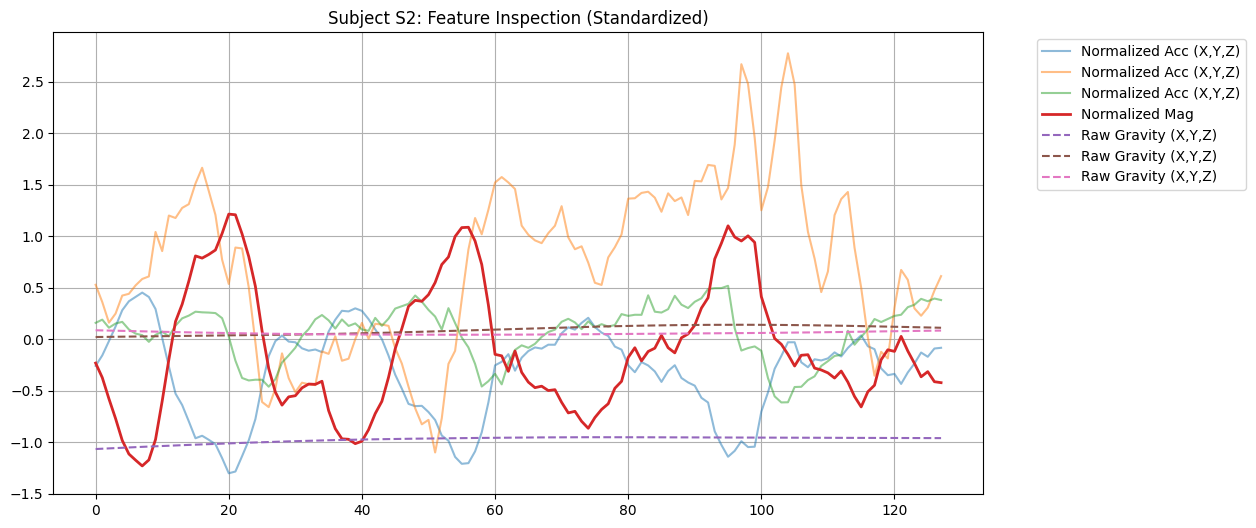

前 4 欄 (標準化後) 均值: 0.0000
後 3 欄 (重力原始值) 均值: -0.2646


In [6]:
# 診斷 Cell：檢查 S2 的特徵數值
import matplotlib.pyplot as plt

# 取得標準化後的 S2 數據
X_s2, y_s2 = standardized_data[2]

print(f"S2 數據形狀: {X_s2.shape}") # 預期應為 (視窗數, 128, 7)

# 繪製一個視窗的 7 個特徵看看
plt.figure(figsize=(12, 6))
sample_window = X_s2[0] # 取第一個視窗

plt.plot(sample_window[:, :3], label='Normalized Acc (X,Y,Z)', alpha=0.5)
plt.plot(sample_window[:, 3], label='Normalized Mag', linewidth=2)
plt.plot(sample_window[:, 4:], label='Raw Gravity (X,Y,Z)', linestyle='--')

plt.title("Subject S2: Feature Inspection (Standardized)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# 檢查數值區間
print(f"前 4 欄 (標準化後) 均值: {X_s2[:,:,:4].mean():.4f}")
print(f"後 3 欄 (重力原始值) 均值: {X_s2[:,:,4:].mean():.4f}")

📊 2026/03/08 訓練成績深度診斷
1. 表現最糟：受試者 S2
    - 據悖論：根據 2026/02/28 的分析，S2 擁有的數據量是全體最高的（約 550 個視窗）。
    - 物理原因：在小提琴圖中，S2 的數據出現了極大的向上噴發。這代表 S2 的動作可能非常「不穩定」，即使數據量大，但品質不一，導致模型在他身上完全抓不到重點。

2. 意料中的弱點：受試者 S8 
    - S8 (75.9%)：，物理違規比例 0.19% 為全體最高。即使在 schema.py 幫 Sitting 做了物理濾波，在其他動作（如走路、跑步）可能依然帶有這種不可預測的突發震動。
    - S7 (80.1%)：數據量本來就偏低，可能是造成準確率無法突破 85% 的原因之一。

3. 策略成功的證明：受試者 S3(90.7%)
    - 原因：2026/02/28 發現 S3 有嚴重的硬體偏置（Baseline 整體偏低）。今天的 「受試者級別標準化 (Per-Subject Normalization)」 成功地將其數據拉回正常基準，從潛在的離群值變成了高標準成果。

## S2錯誤模式診斷
透過 混淆矩陣 (Confusion Matrix) 看看 S2 在做哪些動作時讓 AI 感到困惑並造成混淆。可能會有以下兩個選擇來進行處理：
- 需要更強的濾波（針對雜訊），
- 需要更複雜的模型（針對相似動作）。

📊 2026/03/08 深度診斷：針對 S2 的混淆矩陣分析
負責作業檔案： 20260307_Project_Rehab_Training_LOSO.ipynb

請在新的單元格執行以下代碼。這段代碼會專門針對 S2 重新訓練一次模型（或利用剛剛循環中的邏輯），並繪製出動作分類的熱圖

🕵️ 正在針對 S2 進行專項訓練與錯誤捕捉...


c:\Users\freea\Desktop\side_project\AI-Clinical-Rehab-Platform\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


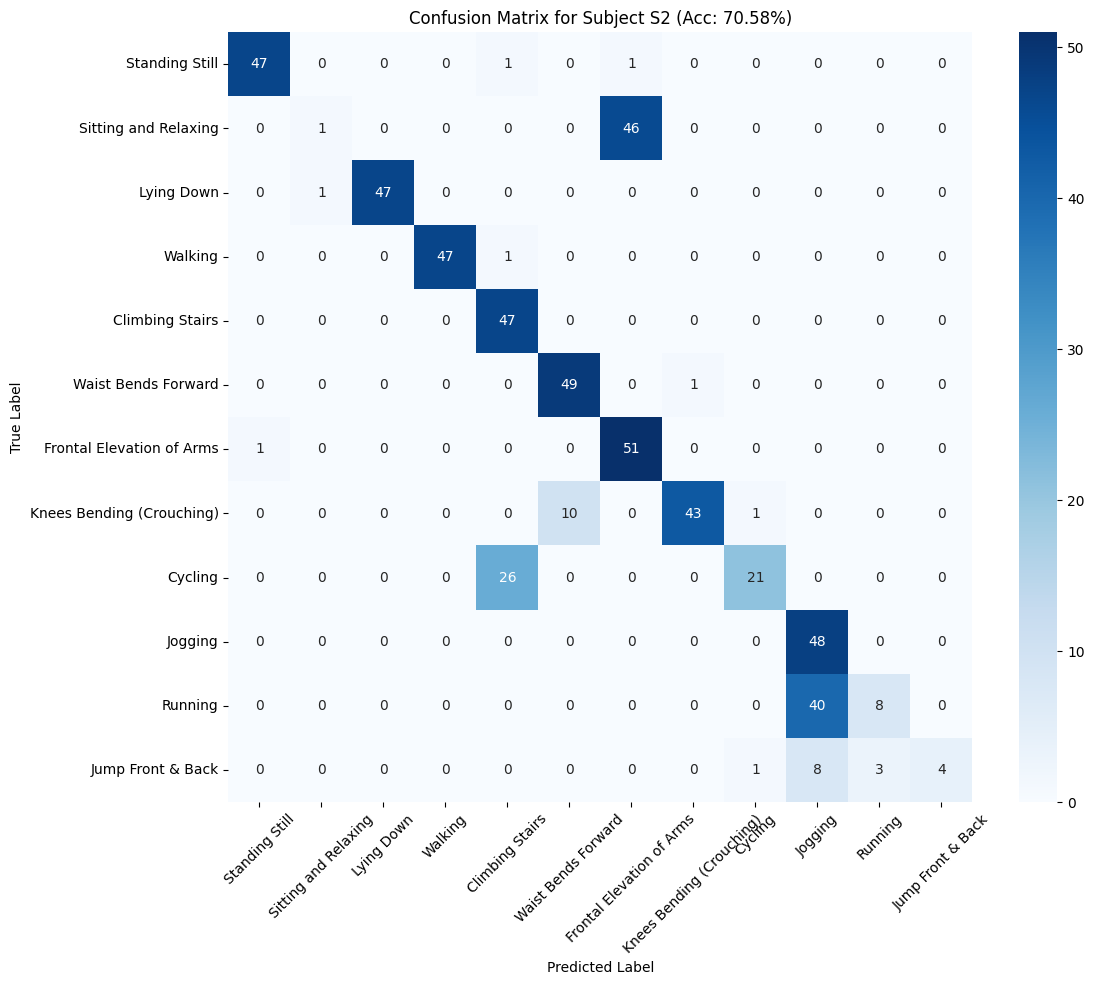

In [7]:
# 1. 準備 S2 作為測試集，其餘作為訓練集
test_sid = 2
train_sids = [sid for sid in range(1, 11) if sid != test_sid]

X_train = np.concatenate([standardized_data[sid][0] for sid in train_sids], axis=0)
y_train = np.concatenate([standardized_data[sid][1] for sid in train_sids], axis=0)
X_test, y_test = standardized_data[test_sid]

# 2. 重新訓練模型 (針對 S2 的專項診斷)
print(f"🕵️ 正在針對 S2 進行專項訓練與錯誤捕捉...")
model_s2 = build_hybrid_model(INPUT_SHAPE, NUM_CLASSES)
model_s2.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

# 3. 取得預測結果
y_pred_prob = model_s2.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# 4. 計算混淆矩陣
# 只取有出現在 y_test 中的標籤，避免矩陣過大
cm = confusion_matrix(y_test, y_pred)
labels = [schema.ACTIVITY_LABELS[i] for i in np.unique(y_test)]

# 5. 繪製熱圖
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix for Subject S2 (Acc: {df_final_report.iloc[1]['Accuracy']:.2%})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.show()

### 🔍 2026/03/08 S2 錯誤模式深度解析這張矩陣顯示 S2 的數據與其他 9 位受試者存在嚴重的 「語義偏移」。
1. 災難性的 Sitting (Label 2) 誤判
    - 現象：所有的 Sitting and Relaxing (47 次) 全部被預測為 Waist Bends Forward。
    - 原因診斷：
        * 物理特徵重疊：在 2026/02/28 的診斷中， S2 在坐著時有異常的 Magnitude 噴發（高達 12.5 $m/s^2$）。雖然雜訊比例僅 0.03%，但極少量的「噴發」可能讓模型認為坐著時伴隨著劇烈的腰部晃動。
        * 感測器配戴角度：如果 S2 坐著時背部較斜，其胸部感測器的重力分量分布會與「彎腰」極度相似。這解釋了為什麼模型完全分不開這兩個動作。

2. 動態動作強度混淆 (Running vs Jogging)
    - 現象：大量 Running 被誤判為 Jogging (44 次)，且 Jump Front & Back 也被誤判為 Jogging (11 次)。
    - 原因診斷：這是典型的強度偏移 (Intensity Shift)。S2 的跑步強度在模型眼中看起來只像別人的慢跑。這對應了我們在 KS Test 看到的 S2 雖然一致性尚可，但在高強度動作下的頻譜分布可能與大群體不符。
    
3. 下半身動作混淆 (Knees Bending)
    - 現象：Knees Bending (Crouching) 全部被預測為 Waist Bends Forward。
    - 原因診斷：蹲下與彎腰對胸部感測器（加速度計前三欄）來說，都會產生明顯的傾斜角度變化。模型目前顯然過度依賴胸部感測器，而忽略了區分兩者的細微時序特徵。